In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as spop

[*********************100%***********************]  1 of 1 completed
C:\Users\petr\AppData\Local\Temp\ipykernel_21324\3664897128.py:28: RuntimeWarning: invalid value encountered in scalar power
  conditional[t] = (omega + alpha * resid[t-1] ** 2 + beta * conditional[t-1] ** 2) ** (1/2)


Parameters
Mean: -0.0002709313872147996
Omega: 7.829519632106525e-05
alpha: 0.12967396408851353
beta: 0.593254104408501
Long-run vol: 0.01681013853679348
Log-likelihood: 7570.5157118524785


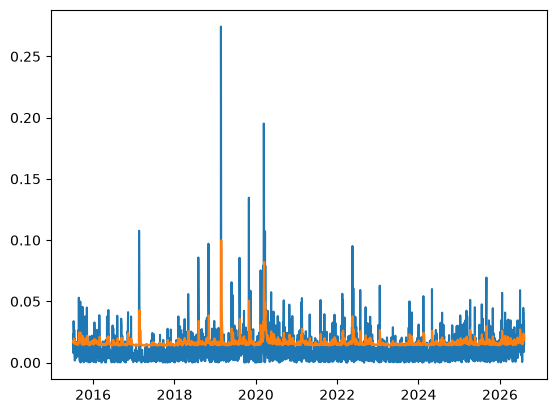

In [56]:
ticker = "KHC"
start = '2010-12-31'
end = '2026-08-08'

prices = yf.download(ticker, start, end)['Close'].squeeze()

returns_pd = prices / prices.shift(1) - 1
returns_pd = returns_pd[1:]

returns = returns_pd.to_numpy()

mean = np.mean(returns)
var = np.std(returns) ** 2

def mle_garch(params):
    mu = params[0]
    omega = params[1]
    alpha = params[2]
    beta = params[3]

    long_run_var = (omega / (1 - alpha - beta)) ** (1/2) # long run variance starting at sample variance = omega

    resid = returns - mu
    conditional = np.zeros(len(returns))
    conditional[0] = long_run_var

    for t in range(1, len(returns)):
        conditional[t] = (omega + alpha * resid[t-1] ** 2 + beta * conditional[t-1] ** 2) ** (1/2)

    likelihood = 1 / ((2 * np.pi) ** (1/2) * conditional) * np.exp(-resid ** 2 / (2 * conditional ** 2))
    log_likelihood = np.sum(np.log(likelihood))

    return -log_likelihood

maximised_log_lhood = spop.minimize(mle_garch, x0=[mean, var, 0, 0], method="Nelder-Mead")

params = maximised_log_lhood.x

mu = params[0]
omega = params[1]
alpha = params[2]
beta = params[3]

log_likelihood = -float(maximised_log_lhood.fun)

long_run_var = (omega / (1 - alpha - beta)) ** (1/2) # long run variance starting at sample variance = omega

resid = returns - mu

conditional = np.zeros(len(returns))
conditional[0] = long_run_var

for t in range(1, len(returns)):
    conditional[t] = (omega + alpha * resid[t-1] ** 2 + beta * conditional[t-1] ** 2) ** (1/2)

print("Parameters")
print(f"Mean: {mu}")
print(f"Omega: {omega}")
print(f"alpha: {alpha}")
print(f"beta: {beta}")
print(f"Long-run vol: {long_run_var}")
print(f"Log-likelihood: {log_likelihood}")

plt.figure(1)
plt.rc('xtick', labelsize=10)
plt.plot(prices.index[1:], abs(resid))
plt.plot(prices.index[1:], conditional)
